# KF Per-Layer Failure Mode Plots

Per-layer **hole rate** (Mode 1) and **missed-truth-layer rate** (Mode 2),
for both UNMATCHED-only and ALL-GT views, attributed to the best KF attempt of each GT particle.

Data: JSONs produced by `acts/output_examples/attribute_holes_per_layer.py`.


In [118]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt


# ── Data dir for ACTS-side JSONs (eff, dropped, attribute_holes, seeding) ─
# Switch this to repoint the whole notebook at a different sample.
DATA_DIR = Path("/data/alice/bkuipers/acts/output_examples/new_batch500")

# ── Path to the directory containing the JSON files ───────────────────────────
PLOT_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/track_metrics/testset_SegmentGNN_GT")

# ── Figure style ──────────────────────────────────────────────────────────────
FIGSIZE      = (7, 5)       # (width, height) in inches
FONT_AXIS    = 18           # axis label font size
FONT_TICK    = 14           # tick label font size
FONT_LEGEND  = 14           # legend font size
FONT_TITLE   = 18           # title font size
CAPSIZE      = 3
MARKERSIZE   = 3 
GRID_ALPHA   = 0.3
DPI          = 150          # set to None to skip saving; otherwise saves next to JSON
AUTO_XLIM    = True         # True: fit x-axis to actual data range; False: use stored xlim

# ── Segment matching specific ─────────────────────────────────────────────────
MIN_BIN_FRACTION = 0.03     # suppress bins with < this fraction of peak-bin count (segment matching plots only)

print(f"Looking for JSON files in: {PLOT_DIR}")
json_files = sorted(PLOT_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s):")
for f in json_files:
    print(f"  {f.name}")

Looking for JSON files in: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/track_metrics/testset_SegmentGNN_GT
Found 0 file(s):


In [119]:
import re

def none_to_nan(lst):
    """Convert a list with None entries back to a numpy array with np.nan."""
    return np.array([np.nan if v is None else v for v in lst], dtype=float)


def _data_xlim(data: dict, pad_fraction=0.08) -> list:
    """Compute xlim from the actual x ± xerr range across all series."""
    lo, hi = np.inf, -np.inf
    for s in data.get("series", []):
        x    = none_to_nan(s["x"])
        xerr = none_to_nan(s["xerr"])
        valid = ~np.isnan(x) & ~np.isnan(s["y"] if isinstance(s["y"], np.ndarray)
                                          else none_to_nan(s["y"]))
        if not np.any(valid):
            continue
        lo = min(lo, float(np.nanmin(x[valid] - xerr[valid])))
        hi = max(hi, float(np.nanmax(x[valid] + xerr[valid])))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    pad = max((hi - lo) * pad_fraction, 0.02)
    return [lo - pad, hi + pad]


def _apply_min_bin_fraction(s: dict, min_bin_fraction: float) -> dict:
    """Return a copy of series s with sparse bins masked to NaN."""
    if "n" not in s:
        return s
    n = none_to_nan(s["n"])
    peak = np.nanmax(n) if np.any(~np.isnan(n)) else 1
    sparse = n < min_bin_fraction * peak
    y      = none_to_nan(s["y"]).copy()
    ylo    = none_to_nan(s["yerr_lo"]).copy()
    yhi    = none_to_nan(s["yerr_hi"]).copy()
    y[sparse] = np.nan
    ylo[sparse] = np.nan
    yhi[sparse] = np.nan
    return {**s, "y": y, "yerr_lo": ylo, "yerr_hi": yhi}


def render_plot(data: dict, figsize=FIGSIZE, save_path=None,
                min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Render one plot from its JSON data dict.

    Returns the Figure so the notebook can display or further tweak it.
    ylabel_fontsize overrides FONT_AXIS for the y-axis label only.
    ylabel overrides the label text stored in the JSON.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for s in data.get("series", []):
        if min_bin_fraction is not None:
            s = _apply_min_bin_fraction(s, min_bin_fraction)
        x       = none_to_nan(s["x"])
        xerr    = none_to_nan(s["xerr"])
        y       = none_to_nan(s["y"])
        yerr_lo = none_to_nan(s["yerr_lo"])
        yerr_hi = none_to_nan(s["yerr_hi"])
        label   = re.sub(r"\s*\(.*?\)\s*$", "", s.get("label", ""))

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=[yerr_lo, yerr_hi],
            fmt=s.get("marker", "o"),
            color=s.get("color", None),
            label=label,
            capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE,
        )

    ax.set_xlabel(data.get("xlabel", ""), fontsize=FONT_AXIS)
    ax.set_ylabel(ylabel if ylabel is not None else data.get("ylabel", ""),
                  fontsize=ylabel_fontsize if ylabel_fontsize is not None else FONT_AXIS)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND)

    if AUTO_XLIM:
        xlim = _data_xlim(data)
        if xlim is not None:
            ax.set_xlim(xlim)
    elif "xlim" in data and data["xlim"] is not None:
        ax.set_xlim(data["xlim"])

    if "ylim" in data and data["ylim"] is not None:
        ax.set_ylim(data["ylim"])

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


def load_and_render(json_path: Path, save_suffix="_replot",
                    min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Load JSON and render. Saves a PDF next to the JSON."""
    with open(json_path) as f:
        data = json.load(f)
    if "title" in data:
        print(data["title"])
    save_path = json_path.with_name(json_path.stem + save_suffix + ".pdf")
    return render_plot(data, save_path=save_path, min_bin_fraction=min_bin_fraction,
                       ylabel_fontsize=ylabel_fontsize, ylabel=ylabel)


print("Helper functions defined.")

Helper functions defined.


Layer thr → dip (muon-driven):
  V13L4   thr=0.108  dip_pT=0.115  eff=0.073
  V13L6   thr=0.150  dip_pT=0.155  eff=0.124
  V13L8   thr=0.198  dip_pT=0.205  eff=0.215
  V17L2   thr=0.246  dip_pT=0.255  eff=0.295
  V17L4   thr=0.306  dip_pT=0.305  eff=0.437
Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/eff_with_dips_replot.pdf


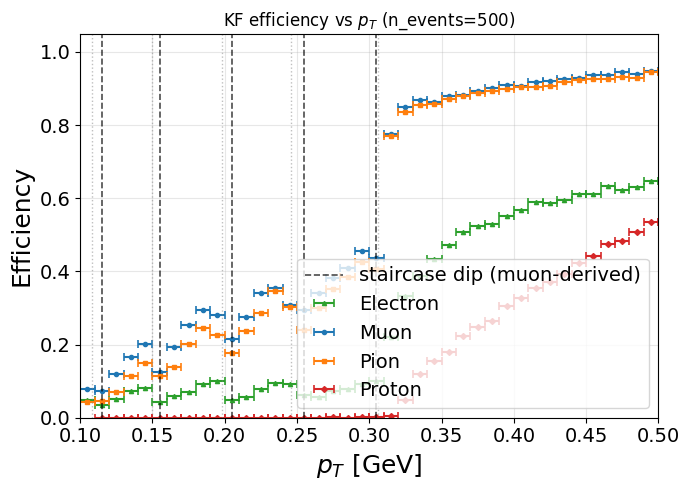

In [120]:
# ── KF efficiency vs pT (all species) + staircase dip detection (muon-only) ──
# Source: acts/output_examples/create_eff_per_particle.py / .C
# Plot efficiency for all 4 species; dips are still derived from the muon
# curve and overlaid as dashed verticals on every per-layer plot below.

EFF_JSON = DATA_DIR / "eff_per_particle.json"

with open(EFF_JSON) as f:
    eff_data = json.load(f)

eff_pt_centers = np.array(eff_data["pt_centers"])
eff_pt_edges   = np.array(eff_data["pt_edges"])

SPECIES_LIST   = ["Electron", "Muon", "Pion", "Proton"]
SPECIES_COLOR  = {"Electron": "#2ca02c", "Muon": "#1f77b4",
                  "Pion": "#ff7f0e", "Proton": "#d62728"}
SPECIES_MARKER = {"Electron": "^", "Muon": "o", "Pion": "s", "Proton": "D"}

eff_by_species = {}
den_by_species = {}
for s in SPECIES_LIST:
    den = np.array(eff_data["den"][s], dtype=float)
    num = np.array(eff_data["num"][s], dtype=float)
    eff_by_species[s] = np.where(den > 0,
                                  num / np.where(den > 0, den, 1), np.nan)
    den_by_species[s] = den

# Muon kept separately — dip detection uses the muon curve only.
mu_den = den_by_species["Muon"]
mu_eff = eff_by_species["Muon"]

# ── Layer geometry (radius in mm) and threshold pT = 0.5 * 0.3 * B * R ──────
B_TESLA = 2.0
LAYER_RADII_MM = {
    "V8L2":   32, "V8L4":   72, "V8L6":  116, "V8L8":  172,
    "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
    "V17L2": 820, "V17L4": 1020,
}
LAYER_PT_THR = {lay: 0.5 * 0.3 * B_TESLA * (R / 1000.0)
                for lay, R in LAYER_RADII_MM.items()}

# Search range: only layers whose threshold lies in [0.1, 0.35] GeV
PT_LO, PT_HI = 0.10, 0.35
NEIGHBOR_HALF_GEV = 0.020   # ±2 bins (bin width ≈ 0.01 GeV)

dip_layers = sorted(((lay, p) for lay, p in LAYER_PT_THR.items()
                     if PT_LO <= p <= PT_HI),
                    key=lambda kv: kv[1])

# Muon-only dip detection: lowest-eff bin within ±NEIGHBOR_HALF_GEV of each thr.
STAIRCASE_DIPS = []   # (layer, threshold_pt, dip_pt, dip_eff)
for lay, thr in dip_layers:
    in_window = (eff_pt_centers >= thr - NEIGHBOR_HALF_GEV) & \
                (eff_pt_centers <= thr + NEIGHBOR_HALF_GEV)
    eff_in = np.where(in_window, mu_eff, np.nan)
    if np.all(np.isnan(eff_in)):
        continue
    j = int(np.nanargmin(eff_in))
    STAIRCASE_DIPS.append((lay, float(thr), float(eff_pt_centers[j]),
                            float(mu_eff[j])))

STAIRCASE_DIP_PT = [dip_pt for _, _, dip_pt, _ in STAIRCASE_DIPS]
print("Layer thr → dip (muon-driven):")
for lay, thr, dip_pt, dip_eff in STAIRCASE_DIPS:
    print(f"  {lay:6s}  thr={thr:.3f}  dip_pT={dip_pt:.3f}  eff={dip_eff:.3f}")

def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
    """Draw dashed verticals at the muon-efficiency staircase dips."""
    for j, p in enumerate(STAIRCASE_DIP_PT):
        ax.axvline(p, color=color, linestyle="--", linewidth=lw, alpha=alpha,
                   zorder=4, label=label if j == 0 else None)

# ── Plot efficiency vs pT for all species ────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)
half_w = 0.5 * (eff_pt_edges[1] - eff_pt_edges[0])
for s in SPECIES_LIST:
    den   = den_by_species[s]
    eff_s = eff_by_species[s]
    valid = den > 0
    ax.errorbar(eff_pt_centers[valid], eff_s[valid], xerr=half_w,
                fmt=SPECIES_MARKER[s], color=SPECIES_COLOR[s],
                markersize=3, capsize=CAPSIZE, capthick=1.2, label=s)
overlay_dips(ax, label="staircase dip (muon-derived)")
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.5)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Efficiency", fontsize=FONT_AXIS)
ax.set_title(f"KF efficiency vs $p_T$ "
             f"(n_events={eff_data.get('n_events','?')})", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.set_xlim(eff_pt_edges[0], eff_pt_edges[-1])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
fig.tight_layout()
out = EFF_JSON.parent / "eff_with_dips_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## KF Failure Modes — UNMATCHED GT Only (per-layer attribution)

Re-attribution of holes & missed-truth-layers using only the **best KF attempt of GT particles that ended up unmatched**. This filters out holes belonging to tracks that still successfully reconstructed their particle (which inflated the original `kf_failure_modes.json` plots).

Theoretical layer thresholds $p_T = 0.15 \cdot B \cdot R$ (B = 2 T) overlaid as triangles on the x-axis.

Data produced by `acts/output_examples/attribute_holes_per_layer.py` (30 events) and saved to `attribute_holes_per_layer.json`.


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_holes_unmatched_muon_replot.pdf


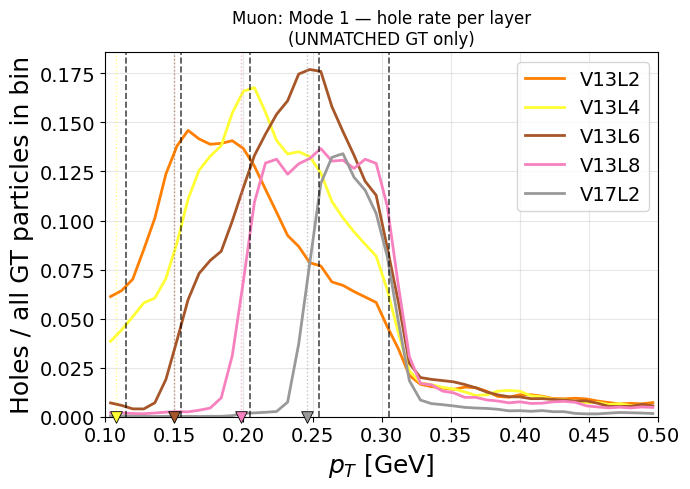

/tmp/ipykernel_291723/4205769511.py:58: RuntimeWarning: invalid value encountered in divide
  out = np.where(den > 0, num / den, np.nan)


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_misses_unmatched_muon_replot.pdf


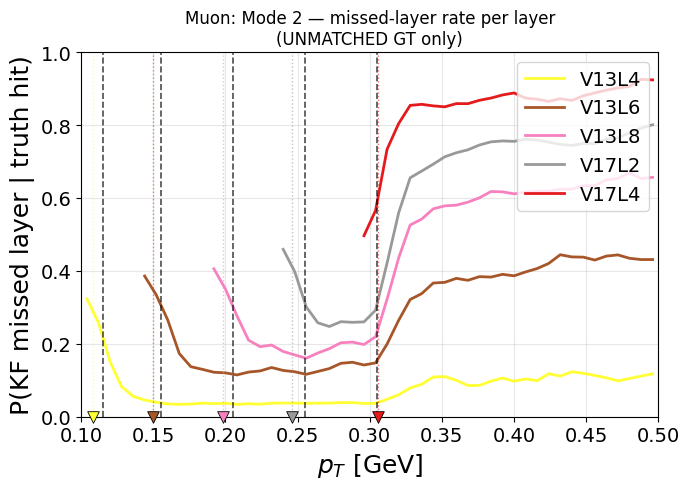

In [121]:
ATTR_JSON = DATA_DIR / "attribute_holes_per_layer.json"

with open(ATTR_JSON) as f:
    attr = json.load(f)

pt_centers = np.array(attr["pt_centers"])
pt_edges   = np.array(attr["pt_edges"])

# Layer (V, L) -> radius [mm], from detector geometry figure
LAYER_RADIUS_MM = {
    ("V8",  "L2"):  32, ("V8",  "L4"):  72, ("V8",  "L6"): 116, ("V8",  "L8"): 172,
    ("V13", "L2"): 260, ("V13", "L4"): 360, ("V13", "L6"): 500, ("V13", "L8"): 660,
    ("V17", "L2"): 820, ("V17", "L4"): 1020,
}
B_TESLA = 2.0

def layer_threshold(lay):
    i = lay.index("L"); key = (lay[:i], lay[i:])
    if key not in LAYER_RADIUS_MM:
        return None
    return 0.5 * 0.3 * B_TESLA * (LAYER_RADIUS_MM[key] / 1000.0)

def layer_radius(lay):
    i = lay.index("L"); return LAYER_RADIUS_MM.get((lay[:i], lay[i:]), 9999)

LAYER_CMAP   = plt.get_cmap("Set1")
PEAK_THRESH  = 0.05    # show layers whose unmatched-hole rate peaks above this
SKIP_VOLUMES = {"V8", "V9"}  # skip pixel layers (thresholds 0.01-0.05 GeV are below pT range)
SKIP_LAYERS  = {"V7L14"}     # skip specific volume+layer combos
SMOOTH_WIN   = 3       # rolling-mean window for line smoothing (set 1 to disable)

def _keep_layer(lay):
    return lay[:lay.index("L")] not in SKIP_VOLUMES and lay not in SKIP_LAYERS

# Stable layer -> color map: order layers by radius, assign deterministic colors
# so the same layer always gets the same color across all plots.
LAYER_COLOR = {
    f"{v}{l}": LAYER_CMAP(i % 9)
    for i, (v, l) in enumerate(sorted(LAYER_RADIUS_MM.keys(),
                                      key=lambda k: LAYER_RADIUS_MM[k]))
}

def layer_color(lay):
    return LAYER_COLOR.get(lay, "black")

def smooth(y, w):
    if w <= 1:
        return y
    valid = ~np.isnan(y)
    if valid.sum() < w:
        return y
    pad = w // 2
    yy  = np.where(valid, y, 0.0)
    ww  = valid.astype(float)
    kernel = np.ones(w) / w
    num = np.convolve(yy, kernel, mode="same")
    den = np.convolve(ww, kernel, mode="same")
    out = np.where(den > 0, num / den, np.nan)
    out[~valid] = np.nan
    return out

for species in ["Muon"]:
    n_total = np.array(attr["n_total"][species])
    mask    = n_total > 0

    # ── Mode 1: hole rate (UNMATCHED GT only) ────────────────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(attr["holes_unmatched"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        holes = np.array(attr["holes_unmatched"][species][lay])
        rate  = np.where(mask, holes / np.where(mask, n_total, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Holes / all GT particles in bin", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 1 — hole rate per layer\n(UNMATCHED GT only)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_holes_unmatched_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Mode 2: conditional missed-layer rate (UNMATCHED only) ───────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(attr["miss_den_unmatched"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        zeros = [0.0] * len(pt_centers)
        num  = np.array(attr["miss_num_unmatched"][species].get(lay, zeros))
        den  = np.array(attr["miss_den_unmatched"][species].get(lay, zeros))
        m    = den > 0
        rate = np.where(m, num / np.where(m, den, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit)", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 2 — missed-layer rate per layer\n(UNMATCHED GT only)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_misses_unmatched_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## KF Failure Modes — ALL GT (per-layer, line plot)

Same per-layer attribution but using the **best KF attempt of every GT particle with at least one attempt** — no matched/unmatched filter. Companion to the UNMATCHED-only view above. Generated alongside the unmatched JSON in a single pass by `attribute_holes_per_layer.py` (same MAX_EVENTS / N_BINS).


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_holes_all_gt_muon_replot.pdf


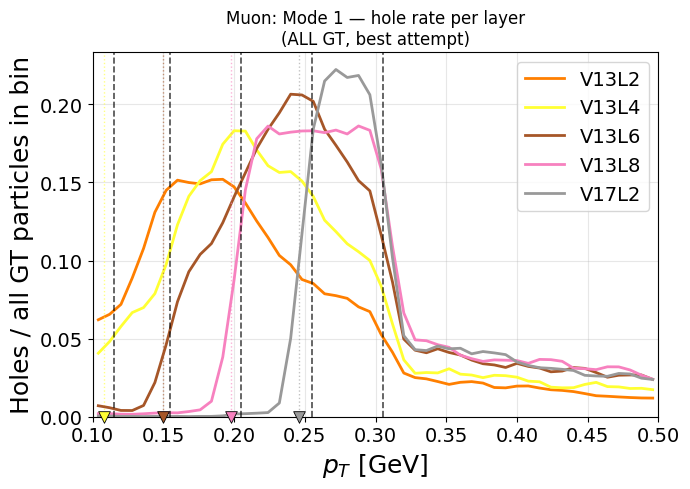

/tmp/ipykernel_291723/4205769511.py:58: RuntimeWarning: invalid value encountered in divide
  out = np.where(den > 0, num / den, np.nan)


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_misses_all_gt_muon_replot.pdf


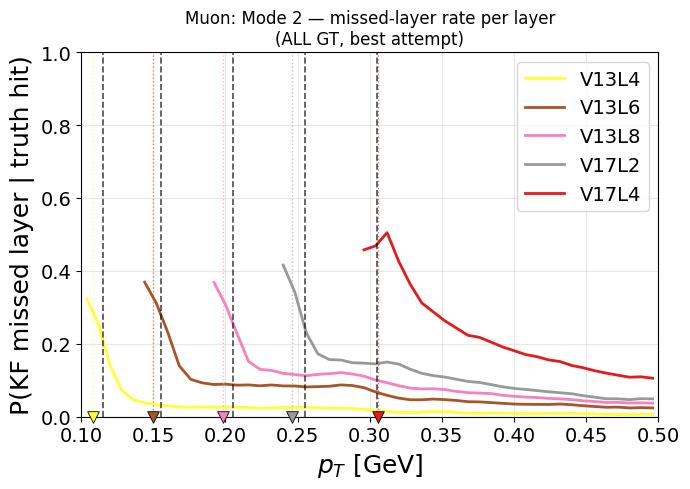

In [122]:
ALL_JSON = DATA_DIR / "attribute_holes_per_layer_all_gt.json"

with open(ALL_JSON) as f:
    allgt = json.load(f)

pt_centers = np.array(allgt["pt_centers"])
pt_edges   = np.array(allgt["pt_edges"])

# (Re-use LAYER_RADIUS_MM, B_TESLA, layer_threshold, layer_radius, smooth, _keep_layer,
#  layer_color from the cell above.)
SKIP_VOLUMES = {"V8", "V9"}  # skip pixel layers (thresholds 0.01-0.05 GeV are below pT range)
SKIP_LAYERS  = {"V7L14"}     # skip specific volume+layer combos
PEAK_THRESH  = 0.05
SMOOTH_WIN   = 3
LAYER_CMAP   = plt.get_cmap("Set1")

def _keep_layer(lay):
    return lay[:lay.index("L")] not in SKIP_VOLUMES and lay not in SKIP_LAYERS

for species in ["Muon"]:
    n_total = np.array(allgt["n_total"][species])
    mask    = n_total > 0

    # ── Mode 1: hole rate (ALL GT, best attempt) ─────────────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(allgt["holes_all"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        holes = np.array(allgt["holes_all"][species][lay])
        rate  = np.where(mask, holes / np.where(mask, n_total, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Holes / all GT particles in bin", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 1 — hole rate per layer\n(ALL GT, best attempt)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_holes_all_gt_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Mode 2: conditional missed-layer rate (ALL GT) ───────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(allgt["miss_den_all"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        zeros = [0.0] * len(pt_centers)
        num  = np.array(allgt["miss_num_all"][species].get(lay, zeros))
        den  = np.array(allgt["miss_den_all"][species].get(lay, zeros))
        m    = den > 0
        rate = np.where(m, num / np.where(m, den, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit)", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 2 — missed-layer rate per layer\n(ALL GT, best attempt)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_misses_all_gt_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## KF Failure Modes — Layer-accumulated (per species)

Sum across all kept layers (respects `SKIP_VOLUMES` / `SKIP_LAYERS`) to give the total per-particle failure rate vs $p_T$.

- **Mode 1 (holes):** $\sum_\ell \text{holes}_\ell\,/\,N_\text{tot}$ — average number of holes per GT particle.
- **Mode 2 (missed layers):** $\sum_\ell \text{miss\_num}_\ell\,/\,\sum_\ell \text{miss\_den}_\ell$ — pooled probability that a truth-hit layer was missed.

Both UNMATCHED-only and ALL-GT views are shown side-by-side.


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_holes_unmatched_accumulated_replot.pdf


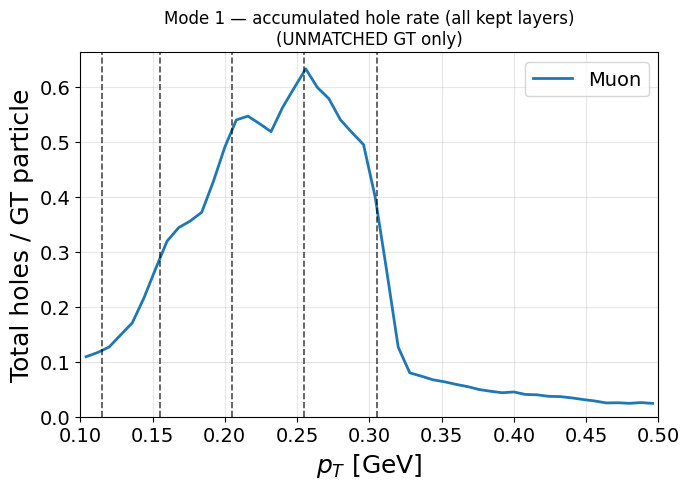

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_holes_all_gt_accumulated_replot.pdf


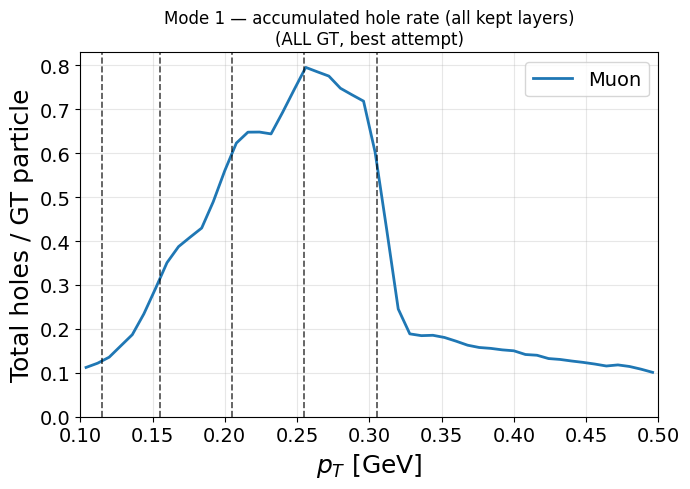

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_misses_unmatched_accumulated_replot.pdf


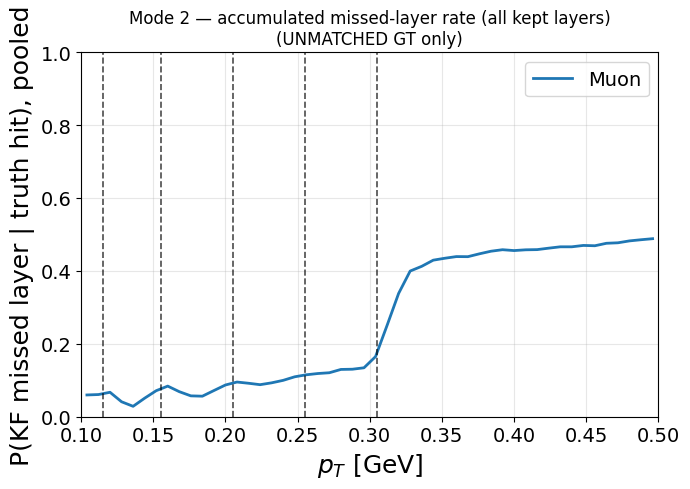

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_misses_all_gt_accumulated_replot.pdf


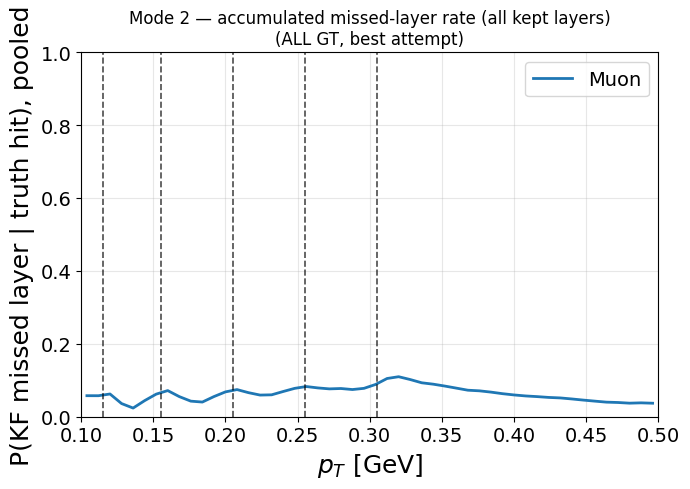

In [123]:
# Layer-accumulated KF failure-mode plots.
# Uses attr (UNMATCHED) and allgt (ALL GT) loaded above, same pt_centers/pt_edges,
# same SKIP_VOLUMES / SKIP_LAYERS / _keep_layer / smooth.

SPECIES_COLOR = {"Muon": "C0", "Pion": "C3"}

def _accumulate_holes(d, species, n_total, mask):
    """Sum holes across kept layers; return rate = total_holes / n_total."""
    layers = [l for l in d[species].keys() if _keep_layer(l)]
    total = np.zeros_like(n_total, dtype=float)
    for lay in layers:
        total += np.array(d[species][lay], dtype=float)
    return np.where(mask, total / np.where(mask, n_total, 1), np.nan)

def _accumulate_misses(num_d, den_d, species):
    """Pool numerator/denominator across kept layers; return num/den."""
    layers = [l for l in den_d[species].keys() if _keep_layer(l)]
    num = np.zeros_like(pt_centers, dtype=float)
    den = np.zeros_like(pt_centers, dtype=float)
    zeros = [0.0] * len(pt_centers)
    for lay in layers:
        num += np.array(num_d[species].get(lay, zeros), dtype=float)
        den += np.array(den_d[species].get(lay, zeros), dtype=float)
    m = den > 0
    return np.where(m, num / np.where(m, den, 1), np.nan)

# ── Mode 1 accumulated: holes per particle ───────────────────────────────────
for view, src, tag in [("UNMATCHED GT only", attr,  "unmatched"),
                       ("ALL GT, best attempt", allgt, "all_gt")]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    holes_key = "holes_unmatched" if tag == "unmatched" else "holes_all"
    for species in ["Muon"]:
        n_total = np.array(src["n_total"][species])
        mask    = n_total > 0
        rate = _accumulate_holes(src[holes_key], species, n_total, mask)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-",
                color=SPECIES_COLOR[species], linewidth=2, label=species)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Total holes / GT particle", fontsize=FONT_AXIS)
    ax.set_title(f"Mode 1 — accumulated hole rate (all kept layers)\n({view})",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_holes_{tag}_accumulated_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

# ── Mode 2 accumulated: pooled missed-layer probability ──────────────────────
for view, src, tag in [("UNMATCHED GT only", attr,  "unmatched"),
                       ("ALL GT, best attempt", allgt, "all_gt")]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    num_key = "miss_num_unmatched" if tag == "unmatched" else "miss_num_all"
    den_key = "miss_den_unmatched" if tag == "unmatched" else "miss_den_all"
    for species in ["Muon"]:
        rate = _accumulate_misses(src[num_key], src[den_key], species)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-",
                color=SPECIES_COLOR[species], linewidth=2, label=species)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit), pooled", fontsize=FONT_AXIS)
    ax.set_title(f"Mode 2 — accumulated missed-layer rate (all kept layers)\n({view})",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_misses_{tag}_accumulated_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## Absolute-count view (Muon, ALL GT)

The Mode 2 ratio `miss_num / miss_den` is conditional on a layer being truly hit, so a low denominator
(few particles even reach the layer in that pT bin) inflates the ratio. To check whether the staircase
dips line up with the actual *number* of failures, plot the raw numerator counts straight from the JSON:

- **Mode 1 abs:** total holes per layer per pT bin — `holes_all[Muon][lay][b]` (no normalisation).
- **Mode 2 abs:** number of GT muon particles whose truth hit on a layer was missed by the KF — `miss_num_all[Muon][lay][b]`.

Dashed verticals are the staircase dips from cell 3.

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_holes_all_gt_muon_absolute_replot.pdf


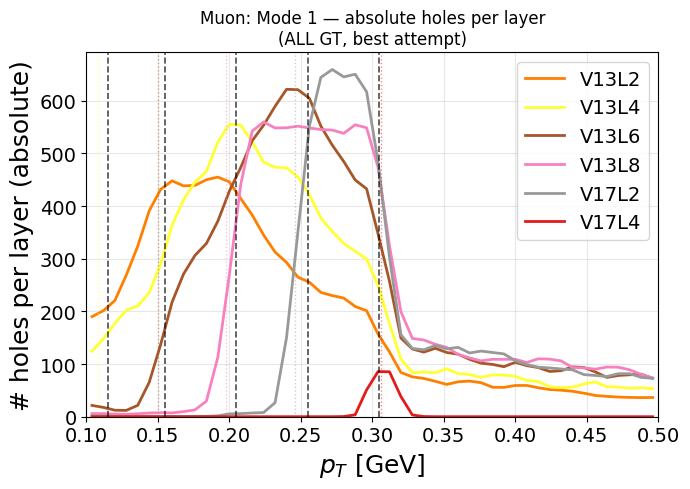

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_misses_all_gt_muon_absolute_replot.pdf


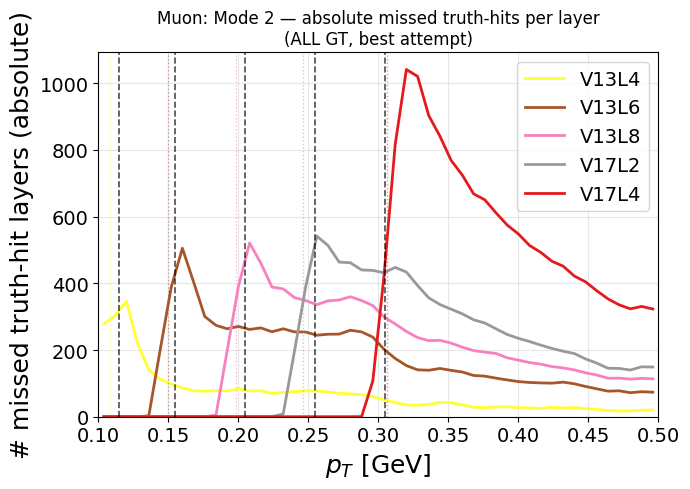

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_miss_denom_all_gt_muon_replot.pdf


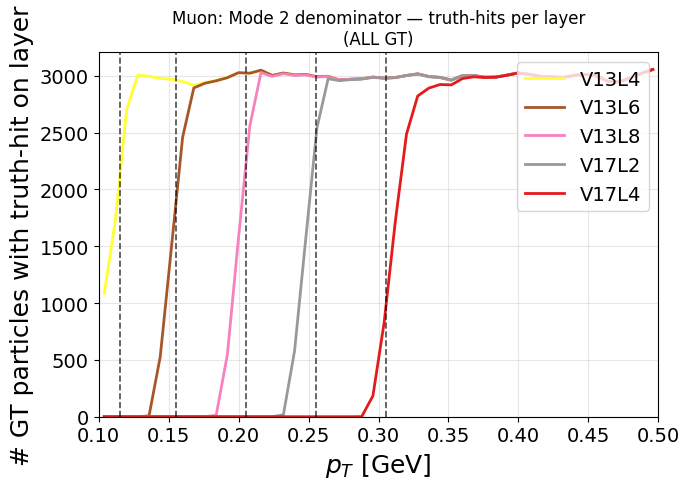

In [124]:
# ── Absolute counts per layer (Muon, ALL GT) ────────────────────────────────
# Plots the raw JSON numerators (no rate normalisation), so the y-axis reflects
# how many failures actually occurred in each pT bin × layer cell.

species = "Muon"
PEAK_THRESH_ABS = 1.0   # show layers whose absolute peak count is at least this

# ── Mode 1 absolute: total holes per layer ──────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["holes_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
for lay in layers:
    holes = np.array(allgt["holes_all"][species][lay], dtype=float)
    if np.nanmax(holes) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(holes, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# holes per layer (absolute)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 1 — absolute holes per layer\n(ALL GT, best attempt)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_holes_all_gt_{species.lower()}_absolute_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# ── Mode 2 absolute: # GT particles whose truth-hit layer was missed by KF ──
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["miss_num_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    miss = np.array(allgt["miss_num_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(miss) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(miss, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# missed truth-hit layers (absolute)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 2 — absolute missed truth-hits per layer\n(ALL GT, best attempt)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_misses_all_gt_{species.lower()}_absolute_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# ── Sanity: GT denominators per layer (how many particles actually reach
#    that layer per pT bin, for Mode 2) — explains low-stats inflation. ─────
fig, ax = plt.subplots(figsize=FIGSIZE)
for lay in layers:
    den = np.array(allgt["miss_den_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(den) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(den, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# GT particles with truth-hit on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 2 denominator — truth-hits per layer\n(ALL GT)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_miss_denom_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## Loop-doubling check: total truth hits per layer (Muon, ALL GT)

The Mode 2 denominator above is binary per particle (≥1 truth hit on layer = 1).
For the doubling-on-loop hypothesis we need the actual hit *count* per layer per pT bin —
sum of all truth hits across particles, with multiplicity preserved.

This is now stored as `truth_hits_all[species][lay][b]` in `attribute_holes_per_layer_all_gt.json`
(re-run `attribute_holes_per_layer.py` after pulling the script change).

Expectation:
- Below an inner layer's threshold: 0 hits.
- Between the layer's threshold and the V17L4 looping threshold (~0.306 GeV): each particle loops
  back through the layer → ~2 hits per particle.
- Above the V17L4 looping threshold: particles exit at V17L4 → ~1 hit per particle.

So inner layers (V13L4, V13L6, V13L8, V17L2) should show a step **down** at ~0.306 GeV
(roughly 2× → 1× per particle). V17L4 itself should show a step **up** at 0.306 GeV (0 → 1).

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_truth_hits_all_gt_muon_replot.pdf


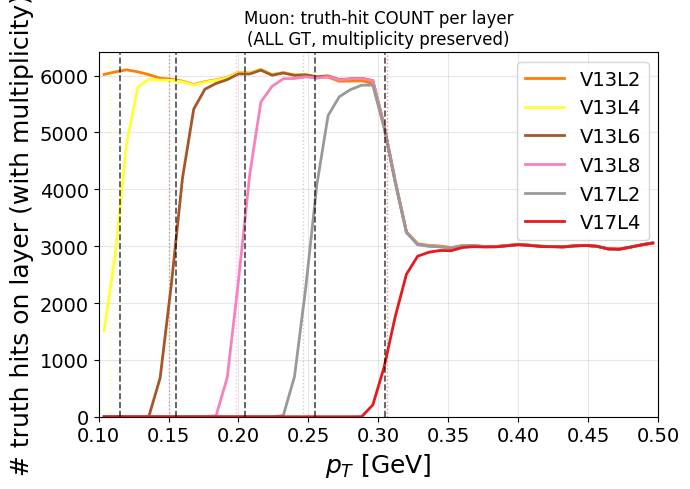

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_truth_hits_per_particle_muon_replot.pdf


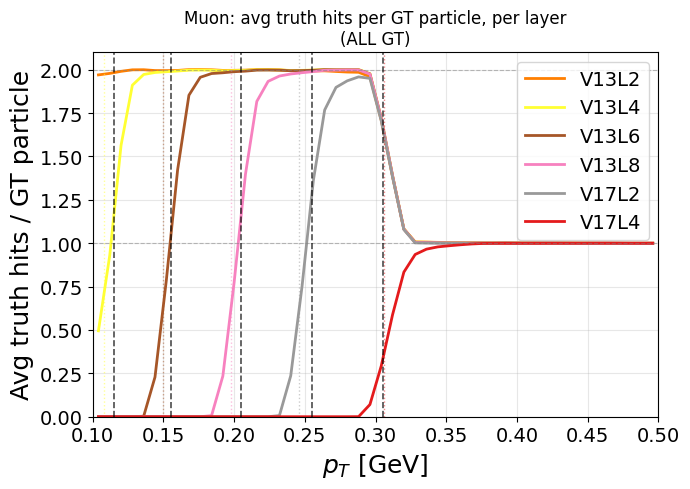

In [125]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Loop-doubling check: truth-hit COUNT per layer (Muon, ALL GT) ───────────
# Same shape as the Mode-2 denominator plot above, but the numerator is the
# raw hit count (multiplicity preserved) instead of "≥1 hit on layer = 1".
# Below the V17L4 loop threshold (~0.306 GeV) inner-layer particles cross each
# reachable layer twice → ~2 hits/particle; above it, once → ~1 hit/particle.
# So the inner-layer curves should sit ~2x higher in the looping band and step
# down at ~0.306 GeV; V17L4 itself should rise from 0 at its threshold.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["truth_hits_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    hits = np.array(allgt["truth_hits_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(hits) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(hits, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# truth hits on layer (with multiplicity)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: truth-hit COUNT per layer\n(ALL GT, multiplicity preserved)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_truth_hits_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Per-particle normalisation: same plot divided by n_with_attempt
fig, ax = plt.subplots(figsize=FIGSIZE)
n_attempt = np.array(allgt["n_with_attempt"][species], dtype=float)
mask = n_attempt > 0
for lay in layers:
    hits = np.array(allgt["truth_hits_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(hits) < PEAK_THRESH_ABS:
        continue
    avg = np.where(mask, hits / np.where(mask, n_attempt, 1), np.nan)
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(avg, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Avg truth hits / GT particle", fontsize=FONT_AXIS)
ax.set_title(f"{species}: avg truth hits per GT particle, per layer\n(ALL GT)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_truth_hits_per_particle_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_n_2hit_all_gt_muon_replot.pdf


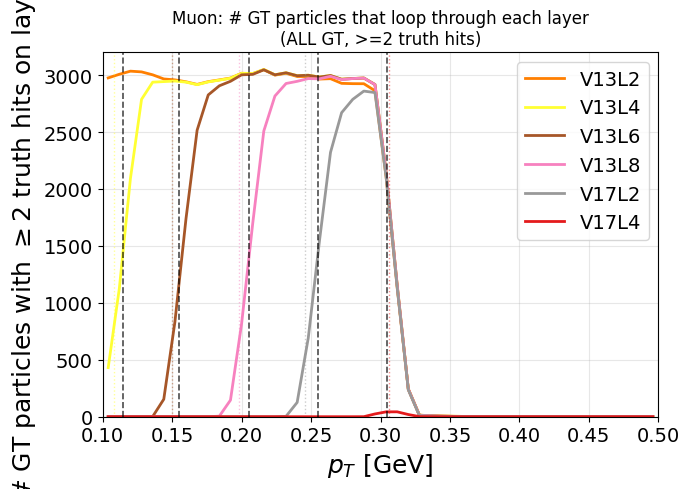

In [126]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── # GT particles with >=2 truth hits on a layer (Muon, ALL GT) ────────────
# Binary per particle on each layer: 1 if the particle deposited at least 2
# truth hits on that layer (i.e. crossed it twice — out + return), else 0.
# Companion to the multiplicity-preserving `truth_hits_all` plot above:
# this plot isolates how many particles actually loop back through each layer.
#
# Expectation: nonzero only between the layer's reach threshold and the
# V17L4 looping threshold (~0.306 GeV); should drop sharply to 0 above that.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["n_2hit_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    n2 = np.array(allgt["n_2hit_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(n2) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(n2, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel(r"# GT particles with $\geq 2$ truth hits on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: # GT particles that loop through each layer\n(ALL GT, >=2 truth hits)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_n_2hit_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_n_1hit_all_gt_muon_replot.pdf


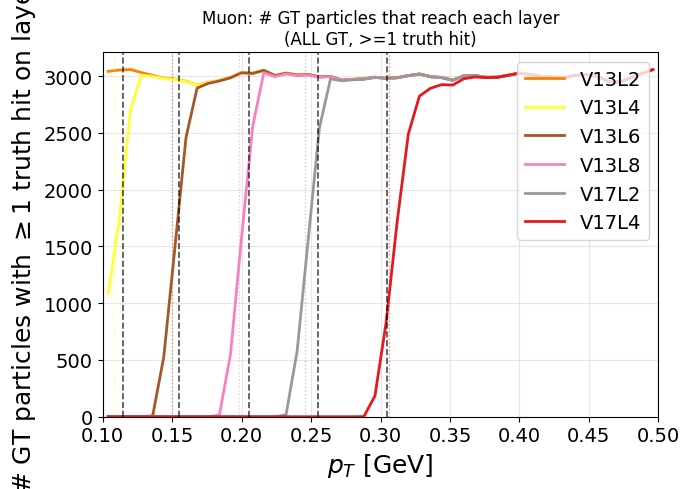

In [127]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── # GT particles with >=1 truth hit on a layer (Muon, ALL GT) ─────────────
# Binary per particle on each layer: 1 if the particle deposited at least one
# truth hit on that layer, else 0. Already stored in `miss_den_all` (it is
# the Mode-2 denominator). Plotting it here as the >=1 companion to the
# >=2 plot above so the two are directly comparable.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["miss_den_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    n1 = np.array(allgt["miss_den_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(n1) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(n1, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel(r"# GT particles with $\geq 1$ truth hit on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: # GT particles that reach each layer\n(ALL GT, >=1 truth hit)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_n_1hit_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_n_1hit_pure_vs_gated_muon_replot.pdf


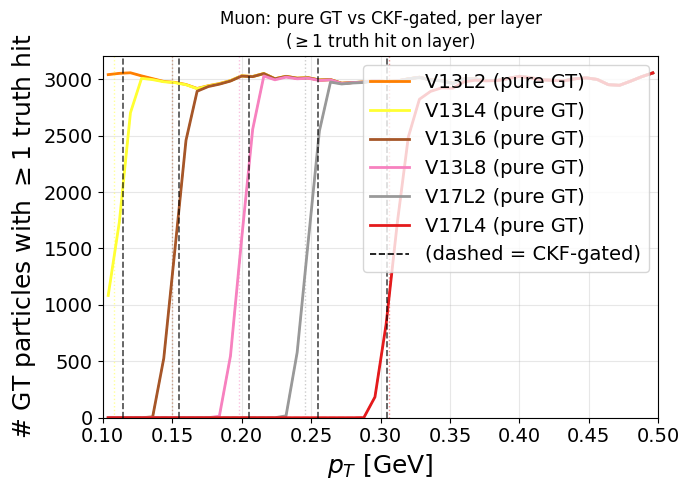

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/attribute_n_2hit_pure_vs_gated_muon_replot.pdf


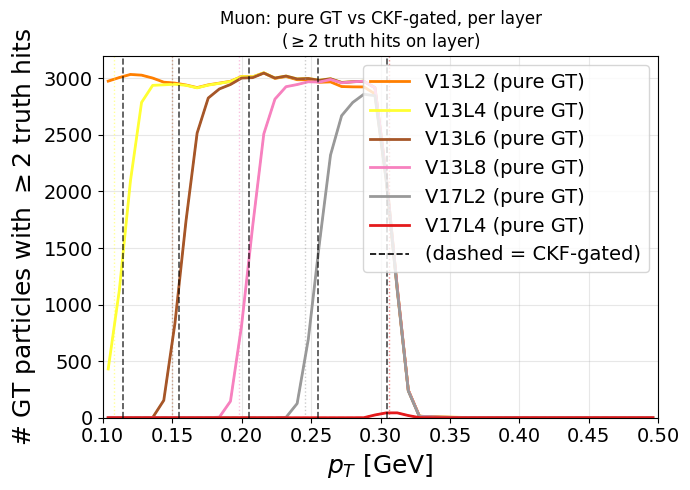

In [128]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Pure-GT vs CKF-gated per-layer truth-hit counts (Muon) ──────────────────
# `miss_den_all` and `n_2hit_all` only count particles that produced a CKF
# track surviving to the matching stage (gated by n_with_attempt). Below we
# plot `n_1hit_pure_gt` and `n_2hit_pure_gt` — counts taken straight from
# hits.root with NO KF-attempt gate. If the dips at outer-layer thresholds
# are a CKF tangent-apex artefact (and not real geometry), the pure-GT
# curves should be smooth where the gated ones dip.

species = "Muon"

for crit_label, gated_key, pure_key, fname in [
    (r"$\geq 1$ truth hit",  "miss_den_all", "n_1hit_pure_gt", "n_1hit"),
    (r"$\geq 2$ truth hits", "n_2hit_all",   "n_2hit_pure_gt", "n_2hit"),
]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers = sorted(allgt[pure_key][species].keys(), key=layer_radius)
    layers = [l for l in layers if _keep_layer(l)]
    zeros  = [0.0] * len(pt_centers)
    for lay in layers:
        pure  = np.array(allgt[pure_key ][species].get(lay, zeros), dtype=float)
        gated = np.array(allgt[gated_key][species].get(lay, zeros), dtype=float)
        if np.nanmax(pure) < PEAK_THRESH_ABS and np.nanmax(gated) < PEAK_THRESH_ABS:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(pure,  SMOOTH_WIN), "-",  color=color,
                linewidth=2, label=f"{lay} (pure GT)")
        ax.plot(pt_centers, smooth(gated, SMOOTH_WIN), "--", color=color,
                linewidth=1.2, alpha=0.8)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
    overlay_dips(ax)
    # Add a single dummy entry to legend explaining solid vs dashed
    from matplotlib.lines import Line2D
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], color="black", linestyle="--",
                          linewidth=1.2, label="(dashed = CKF-gated)"))
    ax.legend(handles=handles, fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel(f"# GT particles with {crit_label}", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: pure GT vs CKF-gated, per layer\n"
                 f"({crit_label} on layer)", fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_{fname}_pure_vs_gated_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/n_total_per_pt_bin_replot.pdf


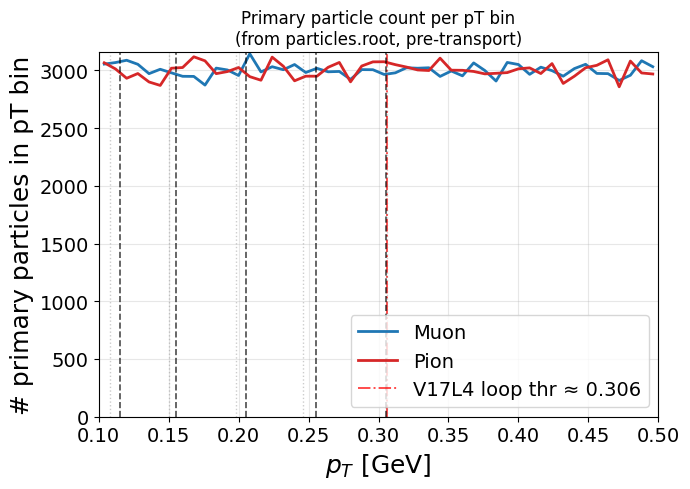


Muon n_total around each layer threshold:
  V13L4   thr=0.108  pT bins:  0.104 0.112 0.120 0.128
            n_total(Muon):     3054 3067 3087 3052
  V13L6   thr=0.150  pT bins:  0.128 0.136 0.144 0.152 0.160 0.168 0.176
            n_total(Muon):     3052 2971 3009 2978 2948 2947 2872
  V13L8   thr=0.198  pT bins:  0.176 0.184 0.192 0.200 0.208 0.216 0.224
            n_total(Muon):     2872 3019 3003 2955 3143 2986 3031
  V17L2   thr=0.246  pT bins:  0.224 0.232 0.240 0.248 0.256 0.264 0.272
            n_total(Muon):     3031 3005 3050 2981 3017 2987 2990
  V17L4   thr=0.306  pT bins:  0.280 0.288 0.296 0.304 0.312 0.320 0.328
            n_total(Muon):     2921 3006 3005 2964 2978 3022 3018


In [129]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Sanity: GT particle count per pT bin (from particles.root, pre-transport) ─
# This counts every primary the particle gun fired, before Geant4 transport,
# detector geometry, or magnetic field — so it isolates whether the per-layer
# denominator dips are caused by the gun's pT distribution being non-uniform
# at the layer thresholds.
#
# A flat curve here ⇒ the dips in the layer denominator plot are detector-side
# (geometry / acceptance / simulation), not a gun artefact.

n_total_mu = np.array(allgt["n_total"]["Muon"], dtype=float)
n_total_pi = np.array(allgt["n_total"]["Pion"], dtype=float)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(pt_centers, n_total_mu, "-", color="C0", linewidth=2, label="Muon")
ax.plot(pt_centers, n_total_pi, "-", color="C3", linewidth=2, label="Pion")
overlay_dips(ax)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.4, alpha=0.7,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# primary particles in pT bin", fontsize=FONT_AXIS)
ax.set_title("Primary particle count per pT bin\n(from particles.root, pre-transport)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / "n_total_per_pt_bin_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Print the muon counts in and around each dip pT for a quick numeric check.
print("\nMuon n_total around each layer threshold:")
for lay, thr, dip_pt, dip_eff in STAIRCASE_DIPS:
    j = int(np.argmin(np.abs(pt_centers - thr)))
    lo, hi = max(0, j - 3), min(len(pt_centers), j + 4)
    window = " ".join(f"{int(n_total_mu[k]):4d}" for k in range(lo, hi))
    centers_str = " ".join(f"{pt_centers[k]:.3f}" for k in range(lo, hi))
    print(f"  {lay:6s}  thr={thr:.3f}  pT bins:  {centers_str}")
    print(f"            n_total(Muon):     {window}")


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/n_attempt_vs_n_total_replot.pdf


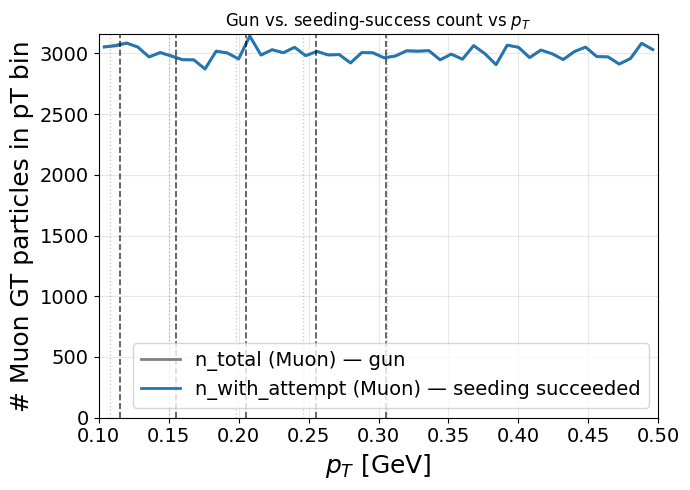

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/seed_eff_muon_replot.pdf


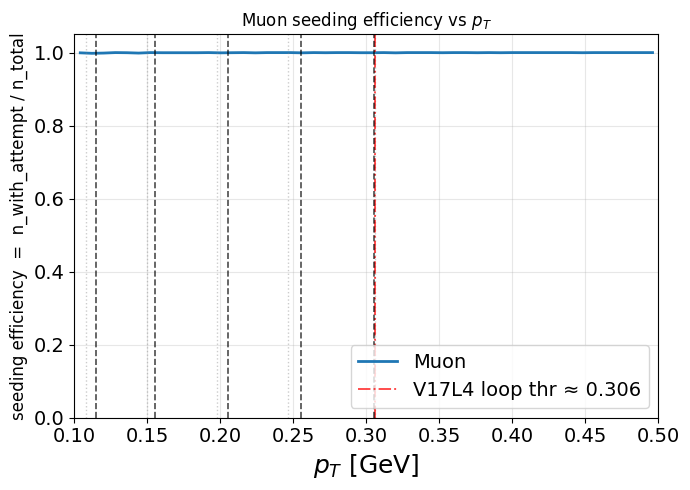


Muon n_attempt / n_total around each layer threshold:
  V13L4   thr=0.108
            pT centers     : 0.104 0.112 0.120 0.128
            n_total        : 3054 3067 3087 3052
            n_with_attempt : 3052 3061 3083 3052
            seed eff       : 1.00 1.00 1.00 1.00
  V13L6   thr=0.150
            pT centers     : 0.128 0.136 0.144 0.152 0.160 0.168 0.176
            n_total        : 3052 2971 3009 2978 2948 2947 2872
            n_with_attempt : 3052 2970 3005 2978 2947 2946 2871
            seed eff       : 1.00 1.00 1.00 1.00 1.00 1.00 1.00
  V13L8   thr=0.198
            pT centers     : 0.176 0.184 0.192 0.200 0.208 0.216 0.224
            n_total        : 2872 3019 3003 2955 3143 2986 3031
            n_with_attempt : 2871 3018 3003 2953 3142 2986 3029
            seed eff       : 1.00 1.00 1.00 1.00 1.00 1.00 1.00
  V17L2   thr=0.246
            pT centers     : 0.224 0.232 0.240 0.248 0.256 0.264 0.272
            n_total        : 3031 3005 3050 2981 3017 2987 2990
    

In [130]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Is the dip a seeding-attempt drop? ──────────────────────────────────────
# `miss_den_all` is the count of particles that (a) have a KF attempt AND
# (b) have a truth hit on the layer. So a dip there can come from EITHER
# (a) failing or (b) failing. The gun (n_total) is flat. Check (a) directly.

n_attempt_mu = np.array(allgt["n_with_attempt"]["Muon"], dtype=float)
seed_eff_mu  = np.where(n_total_mu > 0, n_attempt_mu / n_total_mu, np.nan)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(pt_centers, n_total_mu,    "-", color="grey", linewidth=2,
        label=f"n_total (Muon) — gun")
ax.plot(pt_centers, n_attempt_mu,  "-", color="C0",   linewidth=2,
        label="n_with_attempt (Muon) — seeding succeeded")
overlay_dips(ax)
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# Muon GT particles in pT bin", fontsize=FONT_AXIS)
ax.set_title("Gun vs. seeding-success count vs $p_T$", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / "n_attempt_vs_n_total_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Seeding efficiency
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(pt_centers, seed_eff_mu, "-", color="C0", linewidth=2, label="Muon")
overlay_dips(ax)
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.4, alpha=0.7,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("seeding efficiency  =  n_with_attempt / n_total", fontsize=12)
ax.set_title("Muon seeding efficiency vs $p_T$", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(0, 1.05)
fig.tight_layout()
out = ALL_JSON.parent / "seed_eff_muon_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

print("\nMuon n_attempt / n_total around each layer threshold:")
for lay, thr, dip_pt, _ in STAIRCASE_DIPS:
    j = int(np.argmin(np.abs(pt_centers - thr)))
    lo, hi = max(0, j - 3), min(len(pt_centers), j + 4)
    centers_s = " ".join(f"{pt_centers[k]:.3f}" for k in range(lo, hi))
    ntot_s    = " ".join(f"{int(n_total_mu[k]):4d}" for k in range(lo, hi))
    natt_s    = " ".join(f"{int(n_attempt_mu[k]):4d}" for k in range(lo, hi))
    eff_s     = " ".join(f"{seed_eff_mu[k]:4.2f}" for k in range(lo, hi))
    print(f"  {lay:6s}  thr={thr:.3f}")
    print(f"            pT centers     : {centers_s}")
    print(f"            n_total        : {ntot_s}")
    print(f"            n_with_attempt : {natt_s}")
    print(f"            seed eff       : {eff_s}")


In [131]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Pure seeding efficiency (Muon) vs pT ────────────────────────────────────
# Source: extract_seeding_eff.py (reads estimatedparams.root, runs in seconds
# on a small event subset). For each truth muon: did at least one seed candidate
# with truthMatched=True exist? Binned by truth pT.
#
# Compare against:
#   - gun count               (n_total[Muon])           → flat
#   - seeding+CKF (attempt)   (n_with_attempt[Muon])    → has dips at thresholds
#   - matched (full pipeline) (mu_eff from cell 3)      → staircase dips
#
# If pure seeding efficiency dips at the same pT as n_with_attempt, seeding is
# the bottleneck. If it's flat there, the dips come from later CKF stages.

SEED_JSON = DATA_DIR / "seeding_eff_muon.json"

with open(SEED_JSON) as f:
    seed = json.load(f)

seed_centers = np.array(seed["pt_centers"])
seed_total   = np.array(seed["n_total"], dtype=float)
seed_passed  = np.array(seed["n_seeded"], dtype=float)
seed_eff     = np.where(seed_total > 0,
                        seed_passed / np.where(seed_total > 0, seed_total, 1),
                        np.nan)

# Bring n_with_attempt onto the same grid (it's the same 50-bin 0.1-0.5 layout).
attempt_eff = np.where(n_total_mu > 0,
                       n_attempt_mu / np.where(n_total_mu > 0, n_total_mu, 1),
                       np.nan)
# Bring final-KF eff (40-bin grid) onto the seed grid via interp.
def _interp(x_target, x, y):
    valid = ~np.isnan(y)
    if valid.sum() < 2:
        return np.full_like(x_target, np.nan, dtype=float)
    return np.interp(x_target, x[valid], y[valid], left=np.nan, right=np.nan)
final_eff_on_seed = _interp(seed_centers, eff_pt_centers, mu_eff)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(seed_centers, seed_eff,    "-", color="C2", linewidth=2,
        label=f"seeding only (estimatedparams, n_evt={seed['n_events']})")
ax.plot(pt_centers,    attempt_eff, "-", color="C0", linewidth=2,
        label="seeding + CKF (n_with_attempt / n_total)")
ax.plot(seed_centers, final_eff_on_seed, "-", color="C3", linewidth=2,
        label="full pipeline (matched, from create_eff_per_particle)")
overlay_dips(ax, label="staircase dip")
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.4, alpha=0.7,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Muon efficiency", fontsize=FONT_AXIS)
ax.set_title("Seeding-only vs seeding+CKF vs full-pipeline efficiency",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.set_xlim(seed_centers[0] - 0.005, seed_centers[-1] + 0.005)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
fig.tight_layout()
out = SEED_JSON.parent / "seeding_vs_ckf_vs_matched_eff_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

print("\nSeeding eff around each layer threshold:")
for lay, thr, _, _ in STAIRCASE_DIPS:
    j = int(np.argmin(np.abs(seed_centers - thr)))
    lo, hi = max(0, j - 3), min(len(seed_centers), j + 4)
    centers_s = " ".join(f"{seed_centers[k]:.3f}" for k in range(lo, hi))
    eff_s     = " ".join(f"{seed_eff[k]:4.2f}" for k in range(lo, hi))
    tot_s     = " ".join(f"{int(seed_total[k]):3d}" for k in range(lo, hi))
    print(f"  {lay:6s}  thr={thr:.3f}")
    print(f"            pT centers : {centers_s}")
    print(f"            seed eff   : {eff_s}")
    print(f"            n_total    : {tot_s}")


FileNotFoundError: [Errno 2] No such file or directory: '/data/alice/bkuipers/acts/output_examples/new_batch500/seeding_eff_muon.json'

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/n_total_per_pt_bin_replot.pdf


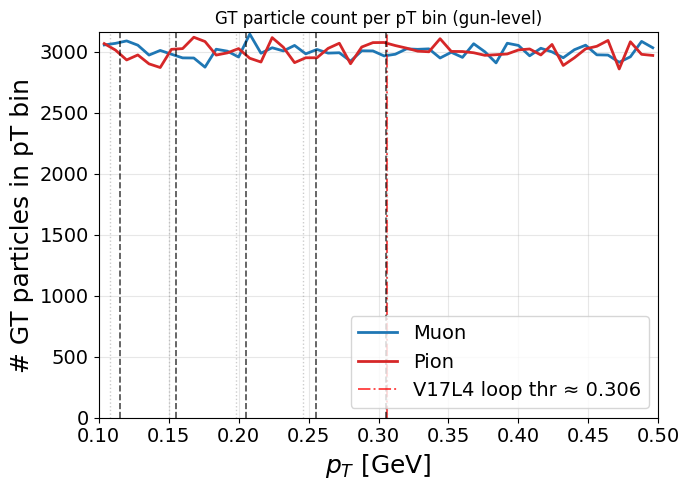


Muon n_total around each layer threshold:
  V13L4   thr=0.108  pT bins:  0.104 0.112 0.120 0.128
            n_total(Muon):     3054 3067 3087 3052
  V13L6   thr=0.150  pT bins:  0.128 0.136 0.144 0.152 0.160 0.168 0.176
            n_total(Muon):     3052 2971 3009 2978 2948 2947 2872
  V13L8   thr=0.198  pT bins:  0.176 0.184 0.192 0.200 0.208 0.216 0.224
            n_total(Muon):     2872 3019 3003 2955 3143 2986 3031
  V17L2   thr=0.246  pT bins:  0.224 0.232 0.240 0.248 0.256 0.264 0.272
            n_total(Muon):     3031 3005 3050 2981 3017 2987 2990
  V17L4   thr=0.306  pT bins:  0.280 0.288 0.296 0.304 0.312 0.320 0.328
            n_total(Muon):     2921 3006 3005 2964 2978 3022 3018


In [ ]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Sanity: muon GT count per pT bin ────────────────────────────────────────
# If the per-layer denominator dips at the next-outer-layer thresholds are
# really just the gun being non-uniform in pT, n_total[Muon][b] will dip at
# the same pT values and the layer-level dips need no further explanation.

n_total_mu = np.array(allgt["n_total"]["Muon"], dtype=float)
n_total_pi = np.array(allgt["n_total"]["Pion"], dtype=float)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(pt_centers, n_total_mu, "-", color="C0", linewidth=2, label="Muon")
ax.plot(pt_centers, n_total_pi, "-", color="C3", linewidth=2, label="Pion")
overlay_dips(ax)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.4, alpha=0.7,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# GT particles in pT bin", fontsize=FONT_AXIS)
ax.set_title("GT particle count per pT bin (gun-level)", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / "n_total_per_pt_bin_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Print the muon counts in and around each dip pT for a quick numeric check.
print("\nMuon n_total around each layer threshold:")
for lay, thr, dip_pt, dip_eff in STAIRCASE_DIPS:
    j = int(np.argmin(np.abs(pt_centers - thr)))
    lo, hi = max(0, j - 3), min(len(pt_centers), j + 4)
    window = " ".join(f"{int(n_total_mu[k]):4d}" for k in range(lo, hi))
    centers_str = " ".join(f"{pt_centers[k]:.3f}" for k in range(lo, hi))
    print(f"  {lay:6s}  thr={thr:.3f}  pT bins:  {centers_str}")
    print(f"            n_total(Muon):     {window}")


Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/dropped_muons_counts_replot.pdf


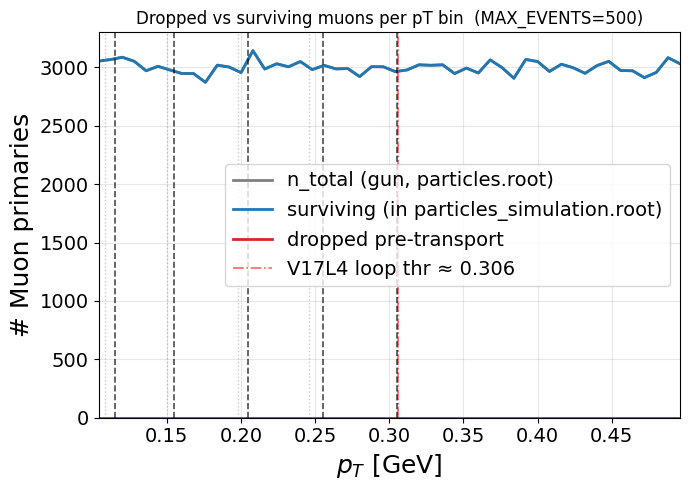

Saved: /data/alice/bkuipers/acts/output_examples/new_batch500/dropped_muons_fraction_replot.pdf


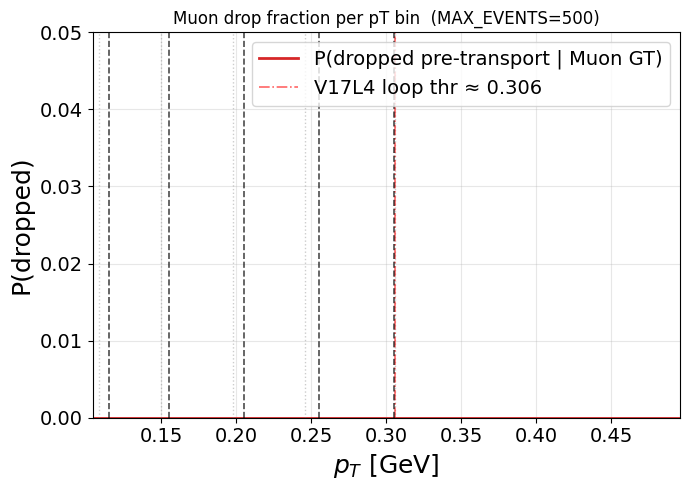

In [ ]:
# self-contained guards
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)
if "dip_layers" not in globals():
    _LAYER_R = {"V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()), key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Dropped muons: in particles.root but missing from particles_simulation.root ─
# These are gun-fired primaries that ACTS' simulation pipeline never propagated
# to completion — they're absent from particles_simulation.root entirely.
# Source: extract_dropped_muons.py
DROPPED_JSON = DATA_DIR / "dropped_muons.json"
with open(DROPPED_JSON) as f:
    drop = json.load(f)

dr_centers = np.array(drop["pt_centers"])
dr_total   = np.array(drop["n_total"], dtype=float)
dr_dropped = np.array(drop["n_dropped"], dtype=float)
with np.errstate(divide="ignore", invalid="ignore"):
    dr_frac = np.where(dr_total > 0,
                       dr_dropped / np.where(dr_total > 0, dr_total, 1),
                       np.nan)

# Counts overlay.
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(dr_centers, dr_total,    "-", color="grey", linewidth=2,
        label="n_total (gun, particles.root)")
ax.plot(dr_centers, dr_total - dr_dropped, "-", color="C0", linewidth=2,
        label="surviving (in particles_simulation.root)")
ax.plot(dr_centers, dr_dropped,  "-", color="C3", linewidth=2,
        label="dropped pre-transport")
overlay_dips(ax)
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# Muon primaries", fontsize=FONT_AXIS)
ax.set_title(f"Dropped vs surviving muons per pT bin  "
             f"(MAX_EVENTS={drop['max_events']})", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="center right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(dr_centers[0], dr_centers[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = DROPPED_JSON.parent / "dropped_muons_counts_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Drop fraction.
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(dr_centers, dr_frac, "-", color="C3", linewidth=2,
        label="P(dropped pre-transport | Muon GT)")
overlay_dips(ax)
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
           label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("P(dropped)", fontsize=FONT_AXIS)
ax.set_title(f"Muon drop fraction per pT bin  "
             f"(MAX_EVENTS={drop['max_events']})", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(dr_centers[0], dr_centers[-1])
ax.set_ylim(0, max(0.05, np.nanmax(dr_frac) * 1.2))
fig.tight_layout()
out = DROPPED_JSON.parent / "dropped_muons_fraction_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()
